# Premium Sunscreen Launch Strategy — Exploratory Data Analysis

Exploring the synthetic Indian cosmetics market data to inform go-to-market
decisions: pricing tier, target cities, competitor gaps, and channel mix.

**Data:** `data/raw/*.csv`, generated by `src/generate_data.py`
**Tools:** pandas for wrangling/plots, DuckDB for SQL-style aggregate queries


In [49]:
import sys
print(sys.executable)

c:\Users\Admin\AppData\Local\Programs\Python\Python314\python.exe


In [50]:
import sys
!{sys.executable} -m pip install duckdb plotly nbformat

In [51]:
import sys
!{sys.executable} -m pip install -r ../requirements.txt

In [52]:
import pandas as pd
import numpy as np
import duckdb
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

RAW_DIR = Path("../data/raw")


## 1. Load data

In [53]:
products = pd.read_csv(RAW_DIR / "Indian_Cosmetics_Products.csv")
customers = pd.read_csv(RAW_DIR / "Customers.csv")
orders = pd.read_csv(RAW_DIR / "Orders.csv")
competitors = pd.read_csv(RAW_DIR / "Competitor_Products.csv")
cities = pd.read_csv(RAW_DIR / "City_Metrics.csv")
channels = pd.read_csv(RAW_DIR / "Marketing_Channels.csv")
insights = pd.read_csv(RAW_DIR / "Customer_Insights.csv")

for name, df in [("products", products), ("customers", customers), ("orders", orders),
                  ("competitors", competitors), ("cities", cities),
                  ("channels", channels), ("insights", insights)]:
    print(f"{name:12s} {df.shape}")


products     (850, 12)
customers    (3500, 11)
orders       (23986, 9)
competitors  (10, 11)
cities       (10, 6)
channels     (6, 5)
insights     (3500, 16)


## 2. DuckDB setup

Registering the pandas DataFrames as DuckDB views so we can query them with
plain SQL — useful for the kind of aggregate/join questions that show up in
consulting case work.

In [54]:
con = duckdb.connect()
for name, df in [("products", products), ("customers", customers), ("orders", orders),
                  ("competitors", competitors), ("cities", cities),
                  ("channels", channels), ("insights", insights)]:
    con.register(name, df)

con.sql("SELECT * FROM products LIMIT 3")


┌────────────┬────────────┬───────────────────────────────┬───────────┬───────┬─────────┬────────┬─────────┬────────┬──────────────┬─────────────┬───────────┐
│ product_id │   brand    │         product_name          │ category  │ price │ size_ml │  spf   │ finish  │ rating │ review_count │ launch_date │ is_luxury │
│  varchar   │  varchar   │            varchar            │  varchar  │ int64 │  int64  │ double │ varchar │ double │    int64     │   varchar   │   int64   │
├────────────┼────────────┼───────────────────────────────┼───────────┼───────┼─────────┼────────┼─────────┼────────┼──────────────┼─────────────┼───────────┤
│ P0001      │ Neutrogena │ Neutrogena Product 0          │ Fragrance │  2499 │      50 │   30.0 │ Glowy   │   3.07 │          149 │ 2022-10-04  │         1 │
│ P0002      │ Forestane  │ Forestane SunGuard 15 Natural │ Sunscreen │   899 │      50 │   15.0 │ Natural │   1.53 │          150 │ 2023-07-17  │         0 │
│ P0003      │ Neutrogena │ Neutrogena Product

## 3. Market overview — pricing & category mix

Where do sunscreens sit relative to the rest of the catalog, and what does
the overall price ladder look like?

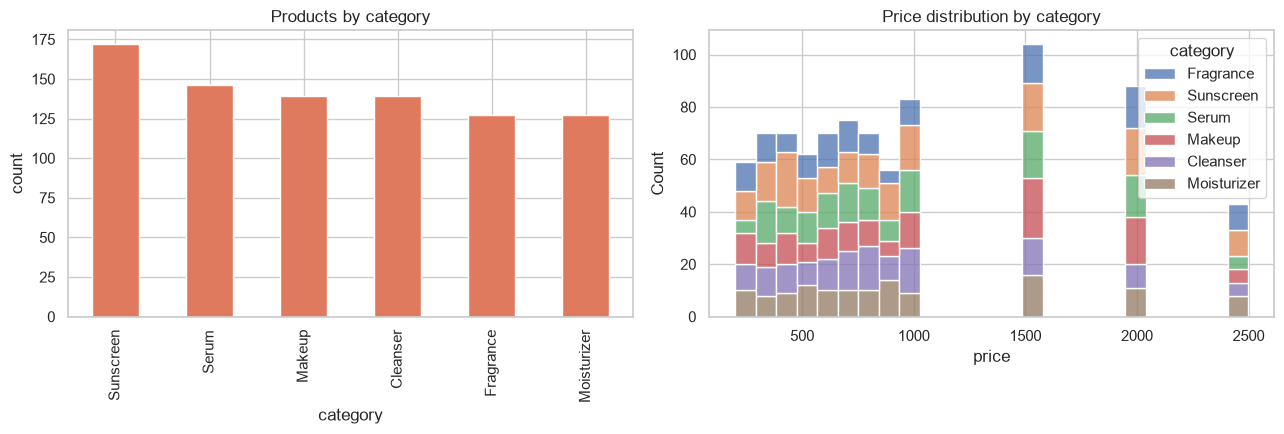

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

products["category"].value_counts().plot(kind="bar", ax=axes[0], color="#e07a5f")
axes[0].set_title("Products by category")
axes[0].set_ylabel("count")

sns.histplot(data=products, x="price", hue="category", bins=25, ax=axes[1], multiple="stack")
axes[1].set_title("Price distribution by category")
plt.tight_layout()
plt.show()


In [56]:
con.sql("""
    SELECT category,
           COUNT(*) AS n_products,
           ROUND(AVG(price), 0) AS avg_price,
           ROUND(AVG(rating), 2) AS avg_rating
    FROM products
    GROUP BY category
    ORDER BY avg_price DESC
""").df()


,category,n_products,avg_price,avg_rating
0,Fragrance,127,1018.0,3.69
1,Makeup,139,997.0,3.59
2,Moisturizer,127,964.0,3.67
3,Sunscreen,172,952.0,3.51
4,Serum,146,947.0,3.55
5,Cleanser,139,877.0,3.59


## 4. Competitor positioning — where's the white space?

Comparing price vs. rating across the 10 tracked competitors to spot gaps:
segments with either weak ratings at a given price point, or no player at
all in a price band.

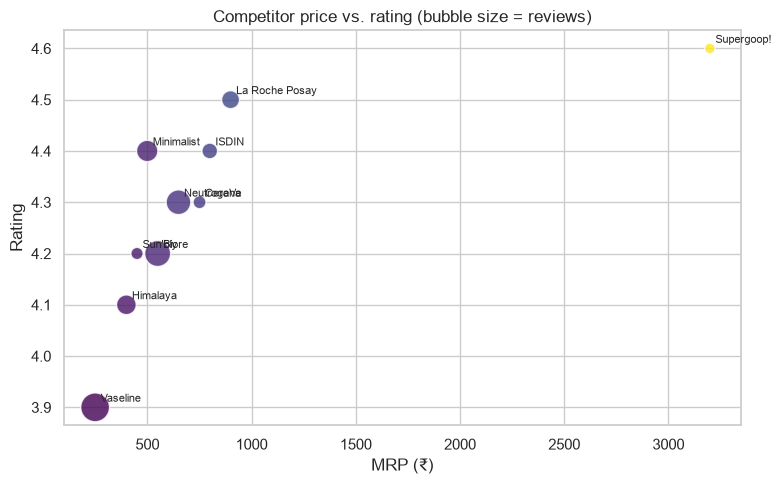

In [57]:
fig, ax = plt.subplots(figsize=(8, 5))
sizes = competitors["reviews"] / competitors["reviews"].max() * 400 + 30
scatter = ax.scatter(competitors["mrp"], competitors["rating"], s=sizes,
                      c=competitors["mrp"], cmap="viridis", alpha=0.8, edgecolor="white")
for _, row in competitors.iterrows():
    ax.annotate(row["brand"], (row["mrp"], row["rating"]), fontsize=8,
                xytext=(4, 4), textcoords="offset points")
ax.set_xlabel("MRP (₹)")
ax.set_ylabel("Rating")
ax.set_title("Competitor price vs. rating (bubble size = reviews)")
plt.tight_layout()
plt.show()


In [58]:
con.sql("""
    SELECT positioning,
           COUNT(*) AS n_brands,
           ROUND(AVG(mrp), 0) AS avg_mrp,
           ROUND(AVG(rating), 2) AS avg_rating,
           SUM(reviews) AS total_reviews
    FROM competitors
    GROUP BY positioning
    ORDER BY avg_mrp
""").df()


,positioning,n_brands,avg_mrp,avg_rating,total_reviews
0,Mass,6,466.0,4.18,125200.0
1,Premium,3,816.0,4.40,25500.0
2,Luxury,1,3199.0,4.60,2500.0


Premium band (₹700–1500) is where most established players cluster.
The ₹900–1500 range with a *mineral/sensitive-skin* angle (like CeraVe) has
fewer entrants and strong ratings — a plausible positioning gap worth
flagging in the strategy doc.

## 5. City-tier opportunity

Which cities combine high skincare spend, high e-commerce penetration, and
manageable competition density — i.e. where launch economics look best?

In [59]:
city_opportunity = con.sql("""
    SELECT city,
           avg_monthly_skincare_spend,
           e_commerce_penetration,
           premium_beauty_density,
           competition_count,
           ROUND(avg_monthly_skincare_spend * e_commerce_penetration
                 / NULLIF(competition_count, 0), 1) AS opportunity_score
    FROM cities
    ORDER BY opportunity_score DESC
""").df()
city_opportunity


,city,avg_monthly_skincare_spend,e_commerce_penetration,premium_beauty_density,competition_count,opportunity_score
0,Mumbai,5525.0,0.71,4.097839,15,261.5
1,Bengaluru,5525.0,0.71,4.270125,15,261.5
2,Delhi,5525.0,0.71,4.062774,16,245.2
3,Chennai,3380.0,0.47,2.588559,9,176.5
4,Kolkata,3380.0,0.47,2.433742,9,176.5
5,Hyderabad,4420.0,0.59,3.354965,15,173.9
6,Pune,4420.0,0.59,3.373819,15,173.9
7,Jaipur,2665.0,0.35,1.830142,6,155.5
8,Lucknow,2665.0,0.35,1.625441,6,155.5
9,Ahmedabad,2665.0,0.35,1.803891,7,133.2


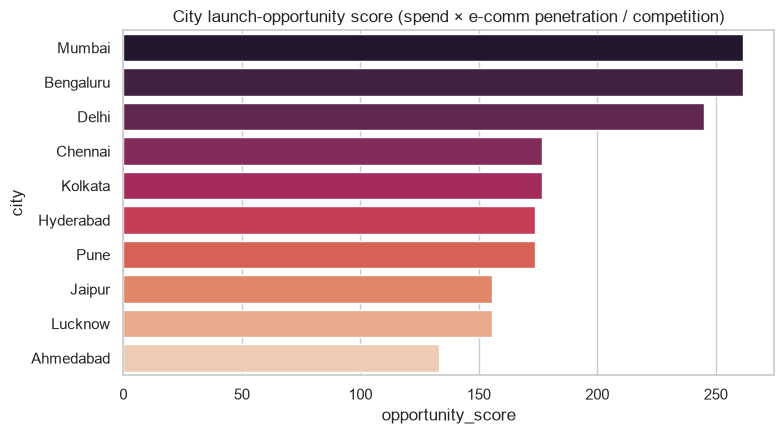

In [60]:
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(data=city_opportunity, x="opportunity_score", y="city",
            hue="city", legend=False, palette="rocket", ax=ax)
ax.set_title("City launch-opportunity score (spend × e-comm penetration / competition)")
plt.tight_layout()
plt.show()


## 6. Customer segments

Looking at spend, price sensitivity, and channel preference together to
sketch out a primary target segment.

In [61]:
con.sql("""
    SELECT city_rank,
           price_sensitivity,
           COUNT(*) AS n_customers,
           ROUND(AVG(skincare_spending), 0) AS avg_spending,
           ROUND(AVG(sunscreen_usage), 2) AS avg_sunscreen_usage
    FROM insights
    GROUP BY city_rank, price_sensitivity
    ORDER BY city_rank DESC, avg_spending DESC
""").df()


,city_rank,price_sensitivity,n_customers,avg_spending,avg_sunscreen_usage
0,5,Low,297,1297.0,2.33
1,5,High,559,1275.0,2.38
2,5,Medium,596,1172.0,2.36
3,4,Medium,261,1287.0,2.36
4,4,High,275,1251.0,2.30
5,4,Low,126,1233.0,2.13
6,3,Medium,232,920.0,2.39
7,3,Low,120,903.0,2.38
8,3,High,223,872.0,2.30
9,2,Low,154,1000.0,2.29


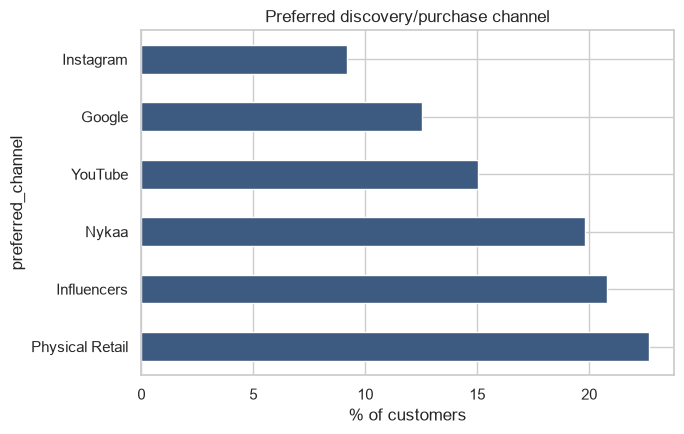

In [62]:
fig, ax = plt.subplots(figsize=(7, 4.5))
channel_pref = insights["preferred_channel"].value_counts(normalize=True) * 100
channel_pref.plot(kind="barh", ax=ax, color="#3d5a80")
ax.set_xlabel("% of customers")
ax.set_title("Preferred discovery/purchase channel")
plt.tight_layout()
plt.show()


## 7. Marketing channel economics

Cost per acquisition vs. conversion rate — where does spend work hardest?

In [63]:
con.sql("""
    SELECT channel,
           cpa_estimate,
           conversion_rate,
           monthly_volume,
           primary_use,
           ROUND(
               CASE WHEN channel = 'Influencers'
                    THEN cpa_estimate / (monthly_volume * conversion_rate / 100.0)
                    ELSE cpa_estimate / (conversion_rate / 100.0)
               END, 2
           ) AS true_cpa
    FROM channels
    ORDER BY true_cpa ASC
""").df()

,channel,cpa_estimate,conversion_rate,monthly_volume,primary_use,true_cpa
0,Influencers,250000.0,0.6,5000000,Trust,8.33
1,Nykaa,0.3,0.9,600,Conversion,33.33
2,Physical Retail,1.8,1.5,400,Trust,120.00
3,Google Ads,3.8,2.5,5000000,Intent,152.00
4,YouTube,3.2,1.2,800000,Education,266.67
5,Instagram,2.5,0.8,1200000,Awareness,312.50


`cpa_estimate` mixes two different cost types: a per-click-style cost for
five channels, and a flat campaign cost for Influencers. `true_cpa` above
corrects for this — Influencers' flat cost is divided across its expected
conversions (`monthly_volume × conversion_rate`), making it comparable
to the per-click channels' cost-per-acquisition (`cpa_estimate ÷ conversion_rate`).
Lower `true_cpa` = cheaper per acquisition = better.


## 8. Key findings (feeds into `reports/`)

- **Pricing:** premium band (₹700–1500) is crowded; a mineral/sensitive-skin
  angle around ₹900–1200 has fewer strong competitors (see CeraVe's positioning).
- **Cities:** Mumbai, Bengaluru, and Delhi rank highest on launch opportunity
  (spend × e-commerce penetration, adjusted for competition) — the strongest
  entry markets despite heavier competition. Chennai/Kolkata are a reasonable
  second wave. Note: cities within the same tier score identically in this
  synthetic dataset (tier-level, not city-level, inputs) — a real launch plan
  would need city-specific data to differentiate within a tier.
- **Customers:** high-spend, low-price-sensitivity segment concentrated in
  Tier 1 cities — natural early-adopter target for a premium launch.
- **Channels:** Influencers is the standout on true cost-per-acquisition
  (₹8.33), far ahead of Nykaa marketplace (₹33.33) and paid digital
  (₹120–313). Worth weighting early launch budget toward influencer
  partnerships, with Nykaa as the next-best channel.

Next: turn this into `reports/` — exported charts + a short market-entry
strategy write-up.